In [2]:
# General view of the data

from sklearn.datasets import fetch_california_housing
import pandas as pd

data = fetch_california_housing(as_frame=True)
df = data.frame

print(df.shape) #Dimension
print("---")
print(df.describe())
print("---")
print(df.isnull().sum())
print("---")
print(df.head)

(20640, 9)
---
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.6923

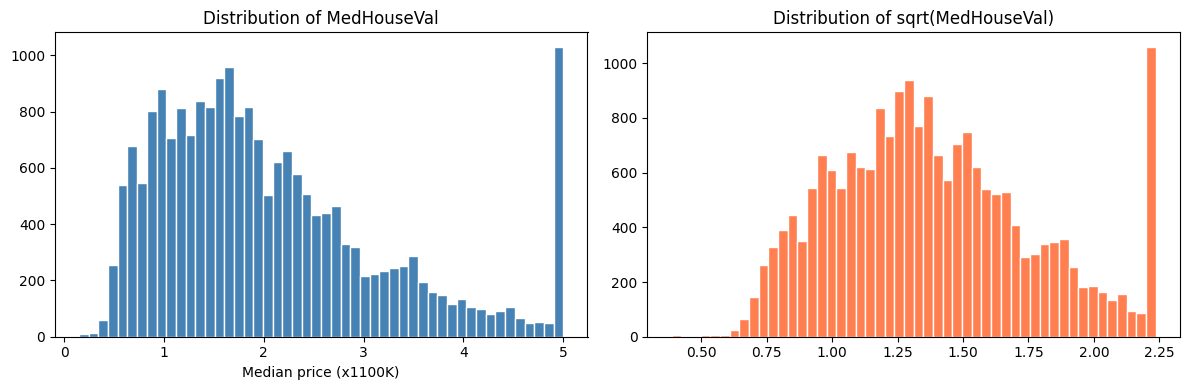

In [3]:
#Distribution of the target variable

import matplotlib.pyplot as plt
import seaborn as sns


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["MedHouseVal"], bins = 50, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution of MedHouseVal")
axes[0].set_xlabel("Median price (x1100K)")

axes[1].hist(df["MedHouseVal"].apply(lambda x: x**0.5), bins=50,color="coral", edgecolor="white")
axes[1].set_title("Distribution of sqrt(MedHouseVal)")

plt.tight_layout()
plt.show()

1. Le graphique de gauche (Bleu) : La réalité brute
Ce graphique représente la distribution originale de ta variable cible, MedHouseVal (le prix médian des maisons).

L'asymétrie (Skewness) : La forme globale n'est pas centrée. La "cloche" penche vers la gauche et s'étire vers la droite. La grande majorité des maisons coûtent entre 1 et 2.5 (donc 100 000$ et 250 000$), mais quelques valeurs très élevées tirent la distribution. Les algorithmes de régression linéaire classique ont souvent du mal avec ce type de répartition asymétrique.

Le fameux plafond (Capping) : Regarde l'énorme barre isolée tout à droite, exactement à la valeur 5. C'est la confirmation visuelle du problème détecté dans ton .describe() ! Toutes les maisons qui valent 500 000$ ou plus ont été artificiellement "bloquées" à cette valeur maximale.

2. Le graphique de droite (Orange) : La tentative de correction
Ici, une transformation mathématique (la racine carrée, ou sqrt) a été appliquée à la colonne des prix. C'est une technique très courante en préparation de données.

L'objectif (réussi) : En appliquant la racine carrée, on "tasse" les très grandes valeurs. Résultat : la forme globale de ton histogramme (si on ignore le pic de la fin) ressemble beaucoup plus à une distribution normale, c'est-à-dire une belle courbe en cloche symétrique. Les modèles prédictifs seront beaucoup plus à l'aise et performants sur des données qui ont cette forme.

Le problème (persistant) : Une transformation mathématique change l'échelle, mais ne règle pas les anomalies de collecte. Le pic artificiel des maisons plafonnées à 5 est toujours bien présent, il a juste été déplacé mathématiquement autour de 2.23 (puisque la racine carrée de 5 donne environ 2.23).

L'impact sur la modélisation
D'un point de vue analytique, cette comparaison t'indique la marche à suivre avant de coder ta régression :

Transformer tes données (avec sqrt ou un logarithme) est une excellente piste pour rendre tes données plus "propres" pour l'algorithme et améliorer tes prédictions.

Malgré la transformation, tu devras prendre une décision pour ce pic artificiel. Si tu laisses ces valeurs plafonnées lors de l'entraînement, ton modèle va apprendre un faux signal (il croira que les caractéristiques de ces maisons mènent toutes exactement au même prix).




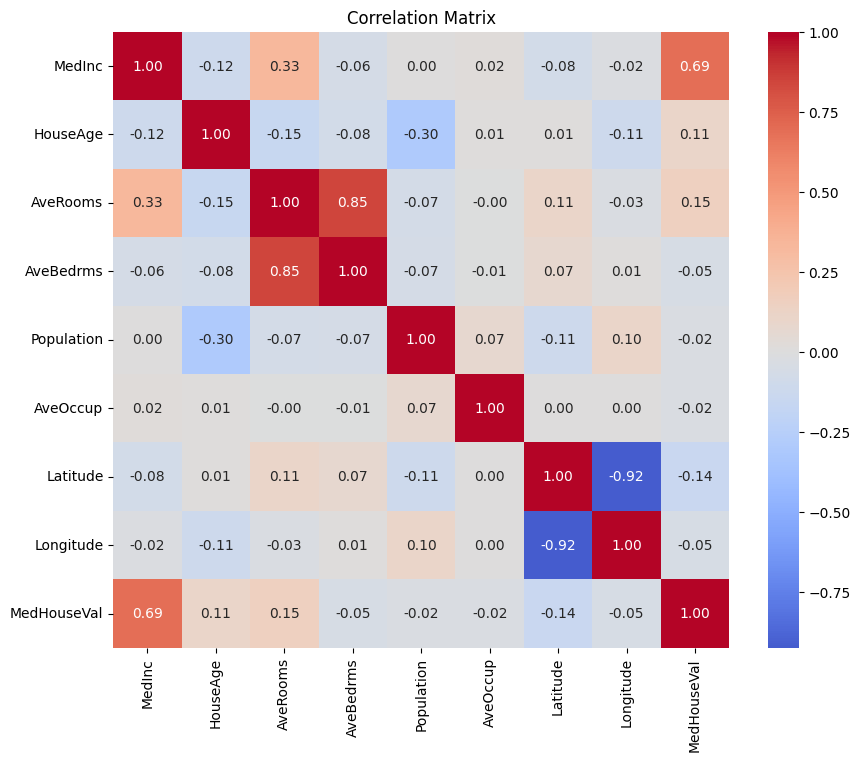

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


In [4]:
#Correlation with target

plt.figure(figsize=(10,8))
corr_matrix = df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot = True,
    fmt=".2F",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Matrix"),
plt.show()

print(corr_matrix["MedHouseVal"].sort_values(ascending=False))

1. le signal fort

**MedInc** est de très loin la variable la plus importante. Une correlation proche de 0.7 indique une relation positive forte. 

2. le signal faible

**AveRooms** et **HouseAge** indique une légère relation positive. Les maisons plus grandes ou plus vieille ont tendance à valoir un petit peu plus her, mais la relation n'est pas nette.

3. le reste constitue du bruit.


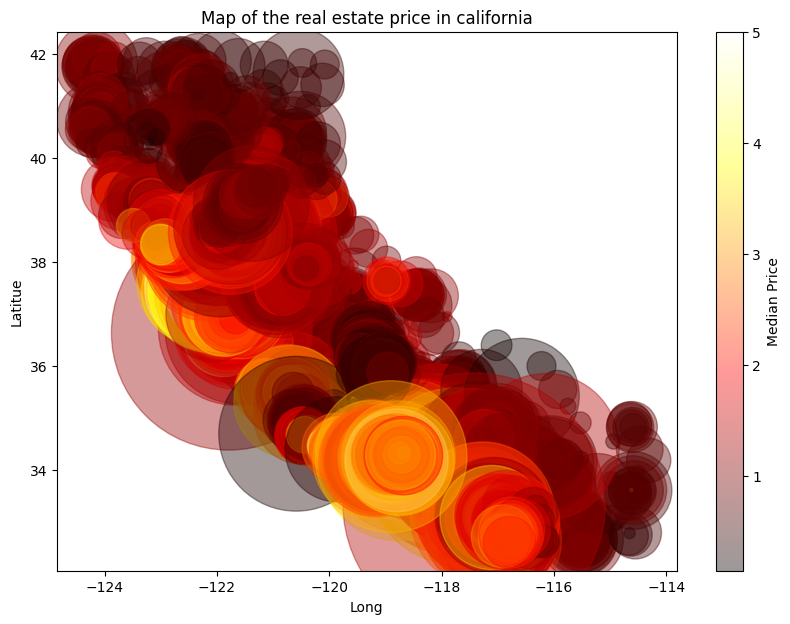

In [5]:
#1.4 Visualisation géohraphique

plt.figure(figsize=(10,7))

scatter = plt.scatter(
    df["Longitude"],
    df['Latitude'],
    c = df["MedHouseVal"],
    cmap= "hot",
    alpha= 0.4,
    s = df["Population"]
)

plt.colorbar(scatter, label="Median Price")
plt.title("Map of the real estate price in california")
plt.xlabel("Long"),
plt.ylabel('Latitue')
plt.show()

In [6]:
#Step 2 : Feature engineering

#before

print(f'Initial size: {df.shape[0]} lines')

#Delete the 500 K threshold

df_clean = df[df["MedHouseVal"]< 5.0].copy()

#print the new dataset shape

print(f'After removing the outliers : {df_clean.shape[0]} lines')
print(f'deleted lines : {df.shape[0] - df_clean.shape[0]}')

Initial size: 20640 lines
After removing the outliers : 19648 lines
deleted lines : 992


In [7]:
#Enrich the dataset

# Rooms par foyer
df_clean["rooms_per_household"] = df_clean["AveRooms"] / df_clean["AveOccup"]

# Bedrooms ratio
df_clean["bedrooms_ratio"] = df_clean["AveBedrms"] / df_clean["AveRooms"]

# Population par foyer
df_clean["population_per_household"] = df_clean["Population"] / df_clean["AveOccup"]

df_clean[["rooms_per_household", "bedrooms_ratio", "population_per_household"]].describe()

,rooms_per_household,bedrooms_ratio,population_per_household
count,19648.000000,19648.000000,19648.000000
mean,1.938814,0.214962,501.192488
std,1.100585,0.056971,383.391367
min,0.002547,0.100000,2.000000
25%,1.498461,0.177648,282.000000
50%,1.911020,0.204555,411.000000
75%,2.248384,0.240908,606.000000
max,55.222222,1.000000,6082.000000


In [8]:
print(df_clean.columns.tolist())

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal', 'rooms_per_household', 'bedrooms_ratio', 'population_per_household']


In [9]:
#Data preprocessing

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#We split the dataset X/y

X = df_clean.drop(columns=["MedHouseVal"])
y = df_clean['MedHouseVal']

#Split into 80 % training and 20 test

X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size= 0.2,
    random_state=42
)

#Scale the data 

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train : {X_train.shape[0]} lines, {X_train.shape[1]} features")
print(f"Test  : {X_test.shape[0]} lines")


Train : 15718 lines, 11 features
Test  : 3930 lines


In [10]:
# modelisation

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error,r2_score
import numpy as np

def evaluate(model_name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n📊 {model_name}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")
    return {"rmse": rmse, "mae": mae, "r2": r2}

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

result = {}
result["Linear Regression"] = evaluate("Linear Regression", y_test, y_pred_lr)



📊 Linear Regression
  RMSE : 0.5988
  MAE  : 0.2859
  R²   : 0.6260


In [11]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs= - 1)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

result["Random Forsest"] = evaluate("Random Forest", y_test, y_pred_rf)


📊 Random Forest
  RMSE : 0.4660
  MAE  : 0.1913
  R²   : 0.7735


In [12]:
import xgboost as xgb


xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)

result["XGBoost"] = evaluate("XGBoost", y_test, y_pred_xgb)


📊 XGBoost
  RMSE : 0.4304
  MAE  : 0.1776
  R²   : 0.8068


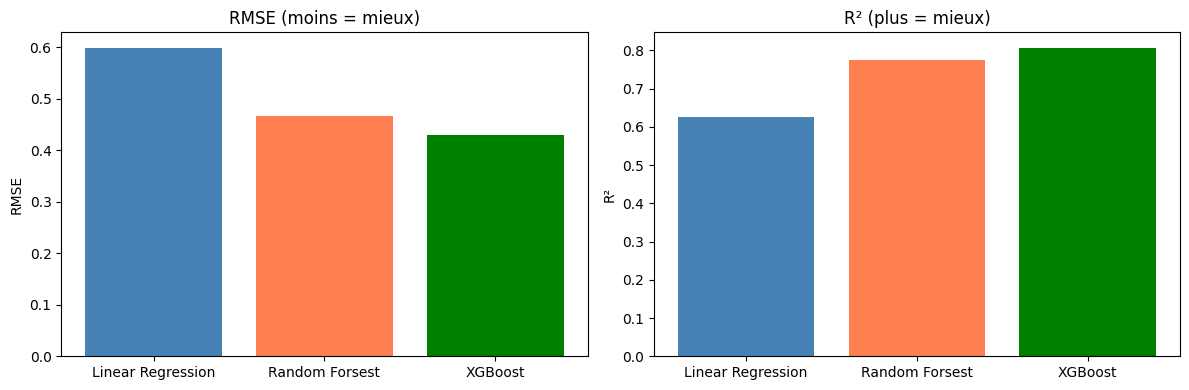

In [13]:
import matplotlib.pyplot as plt

models = list(result.keys())
rmses  = [result[m]["rmse"] for m in models]
r2s    = [result[m]["r2"]   for m in models]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(models, rmses, color=["steelblue", "coral", "green"])
axes[0].set_title("RMSE (moins = mieux)")
axes[0].set_ylabel("RMSE")

axes[1].bar(models, r2s, color=["steelblue", "coral", "green"])
axes[1].set_title("R² (plus = mieux)")
axes[1].set_ylabel("R²")

plt.tight_layout()
plt.show()

In [14]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators"    : [200, 300, 500],
    "max_depth"       : [4, 6, 8],
    "learning_rate"   : [0.01, 0.05, 0.1],
    "subsample"       : [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_base = xgb.XGBRegressor(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator  = xgb_base,
    param_grid = param_grid,
    scoring    = "neg_root_mean_squared_error",
    cv         = 5,        # 5-fold cross validation
    verbose    = 2,        # pour voir la progression
    n_jobs     = -1
)

grid_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=1.0; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=1.0; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=1.0; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=4, n_estimators=200, subsample=0.8; total time=   0.2s
[CV] END 

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [4, 6, ...], 'n_estimators': [200, 300, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computat

In [15]:
# Meilleurs paramètres trouvés
print("Meilleurs paramètres :")
print(grid_search.best_params_)

# Score associé
print(f"\nMeilleur RMSE (CV) : {-grid_search.best_score_:.4f}")

# Évaluation sur le test set
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)

result["XGBoost Tuned"] = evaluate("XGBoost Tuned", y_test, y_pred_best)

Meilleurs paramètres :
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 500, 'subsample': 1.0}

Meilleur RMSE (CV) : 0.4047

📊 XGBoost Tuned
  RMSE : 0.4081
  MAE  : 0.1662
  R²   : 0.8262


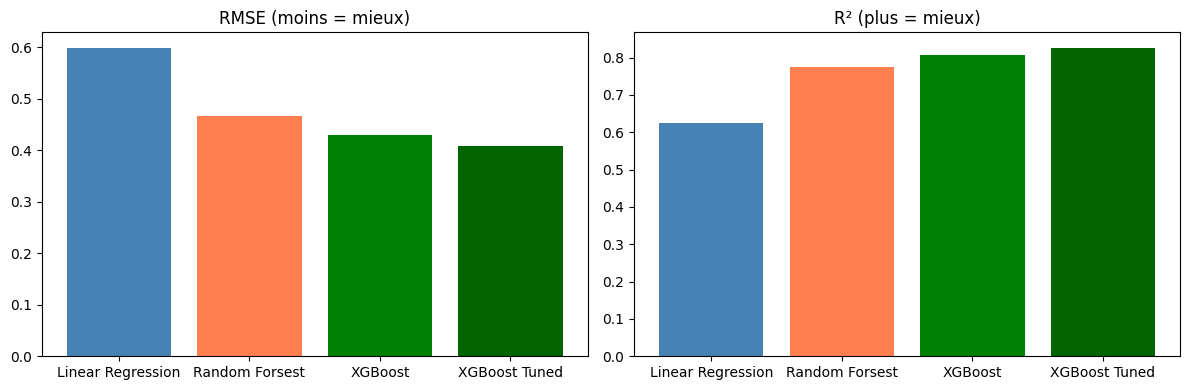

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

models = list(result.keys())
rmses  = [result[m]["rmse"] for m in models]
r2s    = [result[m]["r2"]   for m in models]
colors = ["steelblue", "coral", "green", "darkgreen"]

axes[0].bar(models, rmses, color=colors)
axes[0].set_title("RMSE (moins = mieux)")

axes[1].bar(models, r2s, color=colors)
axes[1].set_title("R² (plus = mieux)")

plt.tight_layout()
plt.show()

 99%|===================| 3905/3930 [01:52<00:00]        

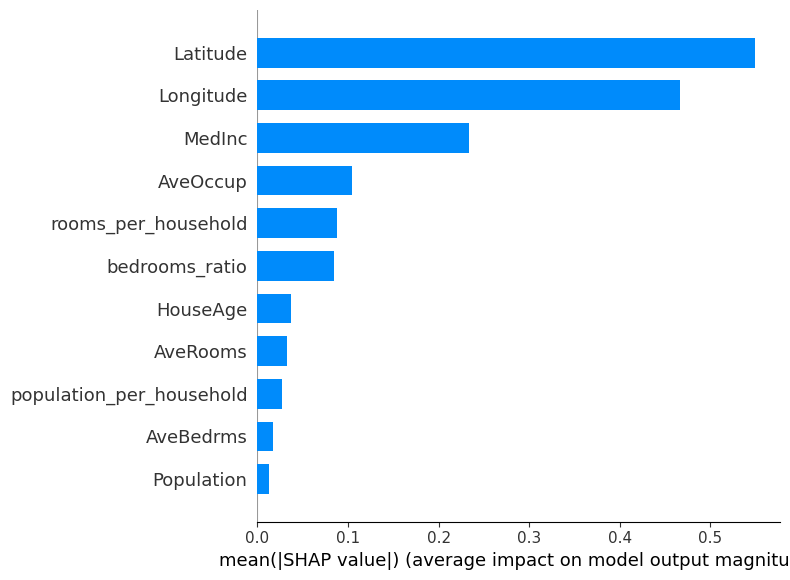

In [17]:
import shap

# Calculer les valeurs SHAP
explainer   = shap.Explainer(best_model, X_train_scaled)
shap_values = explainer(X_test_scaled)

# Graphique 1 — Importance globale des features
shap.summary_plot(shap_values, X_test, plot_type="bar")

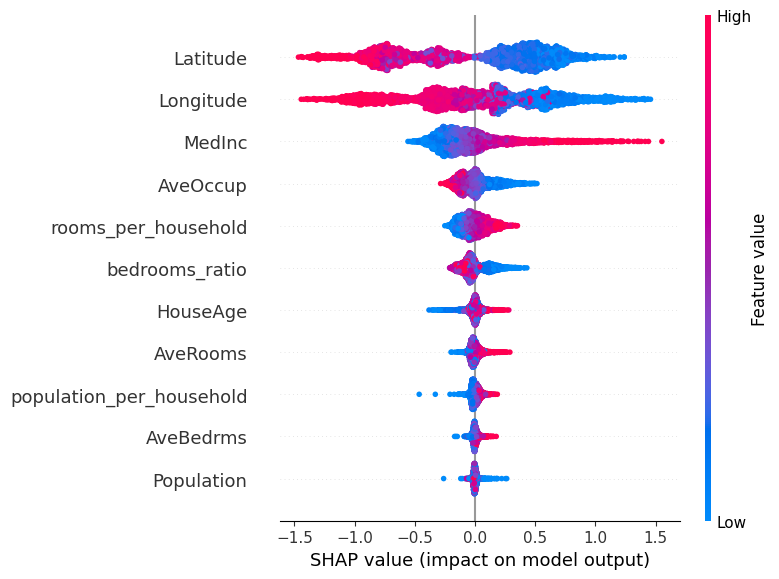

In [18]:
shap.summary_plot(shap_values, X_test)

In [19]:
import joblib
import os

# Créer le dossier models si pas encore fait
os.makedirs("../models", exist_ok=True)

# Sauvegarder le modèle et le scaler
joblib.dump(best_model, "../models/xgb_model.pkl")
joblib.dump(scaler,     "../models/scaler.pkl")

print("✅ Modèle et scaler sauvegardés !")


✅ Modèle et scaler sauvegardés !


In [20]:
df_clean.head(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,rooms_per_household,bedrooms_ratio,population_per_household
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,2.732919,0.146591,126.0
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,2.956685,0.155797,1138.0
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,2.957661,0.129516,177.0
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,2.283154,0.184458,219.0
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,2.879646,0.172096,259.0
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697,2.225182,0.231774,193.0
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992,2.317185,0.192899,514.0
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414,2.682800,0.221327,647.0
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267,2.118574,0.260274,595.0
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611,2.288201,0.199211,714.0


In [21]:
import joblib
import os

# Créer le dossier models/
os.makedirs("../models", exist_ok=True)

# Sauvegarder
joblib.dump(best_model, "../models/xgb_model.pkl")
joblib.dump(scaler,     "../models/scaler.pkl")

print("✅ Modèle et scaler sauvegardés !")

# Vérification — recharger et tester
model_loaded  = joblib.load("../models/xgb_model.pkl")
scaler_loaded = joblib.load("../models/scaler.pkl")

y_pred_check = model_loaded.predict(scaler_loaded.transform(X_test))
print(f"✅ Vérification RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_check)):.4f}")

✅ Modèle et scaler sauvegardés !
✅ Vérification RMSE : 0.4081
